This notebook compares 4 models 

* BLIP (blip-vqa-base): A standard generative VQA model.
* BLIP-2 (blip2-opt-2.7b): A more advanced, resource-intensive generative model.
* GIT (git-base-vqav2): A model that uses a specific prompt template (e.g., "Question: {q}\nAnswer:") for inference.
* ViLT (vilt-b32-finetuned-vqa): A classifier-style VQA model that selects answers from a fixed vocabulary.

In [21]:
# Uncomment below if not already installed
!pip install transformers datasets nltk timm evaluate

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration
from nltk.translate.bleu_score import sentence_bleu
from tqdm import tqdm
from pathlib import Path

In [25]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)

In [6]:
def find_dataset_root() -> Path:
    # Prefer notebook file location; fallback to cwd
    here = Path(globals().get("__file__", Path.cwd())).resolve()
    if here.is_file():
        start = here.parent
    else:
        start = here

    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). Start={start}")

DATASET_ROOT = find_dataset_root()

df_uc = pd.read_csv(DATASET_ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv")
df_uc = df_uc[df_uc['source'] == 'Ulcerative Colitis']
print(f"Total UC QA pairs: {len(df_uc):,}")
df_uc.head()

Total UC QA pairs: 16,890


,source,question,answer,img_id,question_norm,question_type,answer_type
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq,are there any abnormalities in the image check...,Yes/No,Token
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq,are there any anatomical landmarks in the imag...,Yes/No,None/NA
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq,are there any instruments in the image check a...,Yes/No,None/NA
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq,have all polyps been removed,Yes/No,Token
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq,is this finding easy to detect,Yes/No,Yes/No


In [7]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor_blip = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-vqa-base").to(DEVICE)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [8]:
def get_blip_answer(image_path, question):
    image = Image.open(image_path).convert("RGB")
    inputs = processor_blip(image, question, return_tensors="pt").to(DEVICE)
    output = model_blip.generate(**inputs)
    return processor_blip.decode(output[0], skip_special_tokens=True)

In [9]:
from nltk.translate.bleu_score import sentence_bleu

sample_df = df_uc.sample(20, random_state=SEED)
results = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    img_id, question, gt_answer = row['img_id'], row['question'], row['answer']
    img_path = f"./images/{img_id}.jpg"
    if not os.path.exists(img_path):
        continue
    try:
        pred = get_blip_answer(img_path, question)
        bleu = sentence_bleu([gt_answer.split()], pred.split())
        results.append((img_id, question, gt_answer, pred, bleu))
    except Exception as e:
        print(f"Error with {img_id}: {e}")
        continue

results_df = pd.DataFrame(results, columns=["img_id", "question", "ground_truth", "predicted", "bleu"])
results_df.to_csv("blip_uc_results.csv", index=False)
results_df.head()

100%|██████████| 20/20 [00:00<00:00, 19359.82it/s]


,img_id,question,ground_truth,predicted,bleu


In [10]:
# Creating/Recreating a column with the expected local path for each image
import os
df_uc = df_uc.copy()
df_uc['img_path'] = df_uc['img_id'].astype(str).apply(lambda x: f"./images/{x}.jpg")

# Keeping only the rows whose JPEG exists
available_df = df_uc[df_uc['img_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"UC QA rows: {len(df_uc):,}")
print(f"On-disk images found: {len(available_df):,} "
      f"({len(available_df)/max(1,len(df_uc)):.1%} of UC rows)")

# re run BLIP on a safe sample
from nltk.translate.bleu_score import sentence_bleu
from tqdm import tqdm

N_SAMPLES = min(20, len(available_df))  # adjust if you want more/less
sample_df = available_df.sample(N_SAMPLES, random_state=SEED)

results = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    try:
        pred = get_blip_answer(row['img_path'], row['question'])
        bleu = sentence_bleu([str(row['answer']).split()], str(pred).split())
        results.append({
            "img_id": row["img_id"],
            "img_path": row["img_path"],
            "question": row["question"],
            "ground_truth": row["answer"],
            "predicted": pred,
            "bleu": bleu,
        })
    except Exception as e:
        print(f"⚠️ {row['img_id']}: {e}")

import pandas as pd
results_df = pd.DataFrame(results)
print("Collected predictions:", len(results_df))
display(results_df.head())


UC QA rows: 16,890
On-disk images found: 0 (0.0% of UC rows)


0it [00:00, ?it/s]

Collected predictions: 0


""


In [11]:
# !pip install -q transformers datasets timm evaluate nltk sentencepiece accelerate

import os
import math
import json
import time
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import evaluate

# Make sure NLTK has the required data
import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")


In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)

print("Using device:", DEVICE)

def get_uc_sample(available_df, n_samples=30, seed=SEED):
    n = min(n_samples, len(available_df))
    return available_df.sample(n, random_state=seed).reset_index(drop=True)

sample_df = get_uc_sample(available_df, n_samples=30)
len(sample_df), sample_df.head(2)

Using device: cpu


(0,
 Empty DataFrame
 Columns: [source, question, answer, img_id, question_norm, question_type, answer_type, img_path]
 Index: [])

In [13]:
# Unified registry of models and their processors.
# We "lazy load" and cache them the first time they are used.

MODEL_CONFIGS = {
    "blip": {
        "model_name": "Salesforce/blip-vqa-base",
        "processor_cls": ("transformers", "BlipProcessor"),
        "model_cls": ("transformers", "BlipForConditionalGeneration"),
        "task": "generative_vqa",
    },
    "blip2": {
        "model_name": "Salesforce/blip2-opt-2.7b",
        "processor_cls": ("transformers", "Blip2Processor"),
        "model_cls": ("transformers", "Blip2ForConditionalGeneration"),
        "task": "generative_vqa",
        "gen_kwargs": {"max_new_tokens": 30}
    },
    "git": {
        "model_name": "microsoft/git-base-vqav2",
        "processor_cls": ("transformers", "AutoProcessor"),   # resolves to GitProcessor
        "model_cls": ("transformers", "AutoModelForCausalLM"),# resolves to GitForCausalLM
        "task": "generative_vqa_prompt",                      # we pass a text prompt template
        "prompt_template": "Question: {q}\nAnswer:",
        "gen_kwargs": {"max_new_tokens": 20}
    },
    "vilt": {
        "model_name": "dandelin/vilt-b32-finetuned-vqa",
        "processor_cls": ("transformers", "ViltProcessor"),
        "model_cls": ("transformers", "ViltForQuestionAnswering"),
        "task": "classifier_vqa",  # predicts from a fixed VQA answer vocab
    },
}

_model_cache = {}  # format : {key: {"processor": ..., "model": ...}}

def _import(qualified):
    """Import a class given ('module', 'ClassName') tuple."""
    module_name, cls_name = qualified
    module = __import__(module_name, fromlist=[cls_name])
    return getattr(module, cls_name)

def load_model(key):
    """Lazy-load and cache a model+processor by key."""
    if key in _model_cache:
        return _model_cache[key]["processor"], _model_cache[key]["model"]

    cfg = MODEL_CONFIGS[key]
    proc_cls = _import(cfg["processor_cls"])
    mdl_cls  = _import(cfg["model_cls"])

    processor = proc_cls.from_pretrained(cfg["model_name"])
    model = mdl_cls.from_pretrained(cfg["model_name"])

    model = model.to(DEVICE)
    model.eval()

    _model_cache[key] = {"processor": processor, "model": model}
    return processor, model

In [14]:
@torch.inference_mode()
def get_answer_unified(model_key: str, img_path: str, question: str) -> str:
    """
    Runs VQA using the chosen model. Returns a plain answer string.
    Handles generative (BLIP/BLIP2/GIT) and classifier (ViLT) styles.
    """
    cfg = MODEL_CONFIGS[model_key]
    processor, model = load_model(model_key)
    image = Image.open(img_path).convert("RGB")

    task = cfg["task"]

    if task == "generative_vqa":
        # BLIP / BLIP-2 path
        inputs = processor(image, question, return_tensors="pt").to(DEVICE)
        gen_kwargs = cfg.get("gen_kwargs", {})
        out = model.generate(**inputs, **gen_kwargs)
        ans = processor.decode(out[0], skip_special_tokens=True).strip()
        return ans

    elif task == "generative_vqa_prompt":
        # GIT uses a text prompt convention
        prompt = cfg["prompt_template"].format(q=question)
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
        gen_kwargs = cfg.get("gen_kwargs", {})
        generated_ids = model.generate(**inputs, **gen_kwargs)
        ans = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        # Some GIT checkpoints echo the prompt; trim if present
        if "Answer:" in ans:
            ans = ans.split("Answer:")[-1].strip()
        return ans

    elif task == "classifier_vqa":
        # ViLT returns logits over a fixed answer vocab; select argmax id2label
        inputs = processor(image, question, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs)
        logits = outputs.logits
        idx = int(torch.argmax(logits, dim=-1).item())
        # id2label is attached to model.config in this checkpoint
        label = model.config.id2label.get(idx, str(idx))
        return label

    # elif task == "florence2_vqa":
    #     # Florence-2 typically expects a special VQA tag; left as optional
    #     prompt = f"<VQA>{question}"
    #     inputs = processor(text=prompt, images=image, return_tensors="pt").to(DEVICE)
    #     out = model.generate(**inputs, max_new_tokens=30)
    #     ans = processor.batch_decode(out, skip_special_tokens=True)[0].strip()
    #     return ans

    else:
        raise ValueError(f"Unknown task type: {task}")

In [15]:
# --- Metrics: BLEU (NLTK) + ROUGE-L (HF evaluate if available; otherwise pure-Python LCS) ---

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth_fn = SmoothingFunction().method1  # smoothing to avoid BLEU=0 for short strings

# BLEU (sentence-level)
def compute_bleu(pred: str, ref: str) -> float:
    ref_tokens = [str(ref).split()]
    pred_tokens = str(pred).split()
    return float(sentence_bleu(ref_tokens, pred_tokens, smoothing_function=smooth_fn))

# Try to use HuggingFace 'evaluate' for ROUGE-L; if unavailable, fall back to pure-Python LCS-based ROUGE-L
_use_hf_rouge = False
try:
    import evaluate as _hf_evaluate
    _rouge_metric = _hf_evaluate.load("rouge")  # may fail if internet is blocked
    _use_hf_rouge = True
except Exception:
    _use_hf_rouge = False

def _lcs_len(a_tokens, b_tokens):
    # classic DP LCS
    n, m = len(a_tokens), len(b_tokens)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        ai = a_tokens[i-1]
        for j in range(1, m+1):
            if ai == b_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def _rougeL_f1_single(pred: str, ref: str) -> float:
    # token-level ROUGE-L F1 (common for short answers)
    p_tokens = str(pred).split()
    r_tokens = str(ref).split()
    if not p_tokens and not r_tokens:
        return 1.0
    if not p_tokens or not r_tokens:
        return 0.0
    lcs = _lcs_len(p_tokens, r_tokens)
    prec = lcs / max(1, len(p_tokens))
    rec  = lcs / max(1, len(r_tokens))
    if prec + rec == 0:
        return 0.0
    f1 = 2 * prec * rec / (prec + rec)
    return float(f1)

def compute_rougeL(preds, refs) -> float:
    """
    Returns dataset-level ROUGE-L:
    - If HF evaluate is available: uses its aggregate (rougeL).
    - Else: mean of token-level ROUGE-L F1 across examples.
    """
    if _use_hf_rouge:
        scores = _rouge_metric.compute(predictions=list(preds), references=list(refs), use_stemmer=True)
        return float(scores.get("rougeL", 0.0))
    else:
        if len(preds) == 0: 
            return 0.0
        vals = [_rougeL_f1_single(p, r) for p, r in zip(preds, refs)]
        return float(sum(vals) / len(vals))

In [17]:
def evaluate_models_on_sample(model_keys, sample_df, out_dir="phase3_results"):
    os.makedirs(out_dir, exist_ok=True)

    summary_rows = []
    per_model_frames = []

    for key in model_keys:
        print(f"\n=== Evaluating {key} ===")
        preds, refs, rows = [], [], []
        start = time.time()

        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
            img_path = row["img_path"]
            q        = str(row["question"])
            ref      = str(row["answer"])

            try:
                pred = get_answer_unified(key, img_path, q)
            except Exception as e:
                pred = f"[ERROR: {e}]"

            bleu = compute_bleu(pred, ref)

            rows.append({
                "model": key,
                "img_id": row["img_id"],
                "img_path": img_path,
                "question": q,
                "ground_truth": ref,
                "predicted": pred,
                "bleu": bleu,
            })
            preds.append(pred)
            refs.append(ref)

        elapsed = time.time() - start
        df = pd.DataFrame(rows)
        per_model_frames.append(df)

        # Aggregate metrics
        bleu_avg = float(df["bleu"].mean()) if not df.empty else float("nan")
        rougeL   = compute_rougeL(preds, refs) if len(df) > 0 else float("nan")

        # Save per-model CSV
        csv_path = os.path.join(out_dir, f"{key}_uc_predictions.csv")
        df.to_csv(csv_path, index=False)

        summary_rows.append({
            "model": key,
            "n_examples": len(df),
            "BLEU_avg": bleu_avg,
            "ROUGE_L": rougeL,
            "time_sec": elapsed,
            "time_per_example_sec": (elapsed / max(1, len(df))),
        })

    summary_df = pd.DataFrame(summary_rows).sort_values(by="BLEU_avg", ascending=False).reset_index(drop=True)

    # Save summary
    summary_path = os.path.join(out_dir, "summary_uc_phase3.csv")
    summary_df.to_csv(summary_path, index=False)

    # Also return the detailed concatenated frame (handy for side-by-side inspection)
    detail_df = pd.concat(per_model_frames, ignore_index=True) if per_model_frames else pd.DataFrame()
    return summary_df, detail_df

In [19]:
# Choose which models to run (you can comment out heavy ones like blip2 on small GPUs)
models_to_run = ["blip", "vilt", "git", "blip2"]  # order is up to you

summary_df, detail_df = evaluate_models_on_sample(models_to_run, sample_df)

print("\n=== Summary (higher is better) ===")
display(summary_df)

print("\n=== A few rows from the combined details ===")
display(detail_df.head(8))


=== Evaluating blip ===


0it [00:00, ?it/s]



=== Evaluating vilt ===


0it [00:00, ?it/s]



=== Evaluating git ===


...

0it [00:00, ?it/s]


=== Summary (higher is better) ===


,model,n_examples,BLEU_avg,ROUGE_L,time_sec,time_per_example_sec
0,blip,0,NaN,NaN,0.001179,0.001179
1,vilt,0,NaN,NaN,0.000778,0.000778
2,git,0,NaN,NaN,0.000772,0.000772
3,blip2,0,NaN,NaN,0.000685,0.000685



=== A few rows from the combined details ===


""


Text(0, 0.5, 'ROUGE-L')

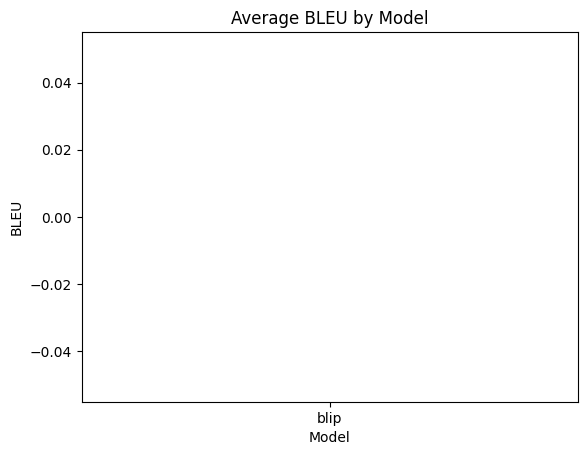

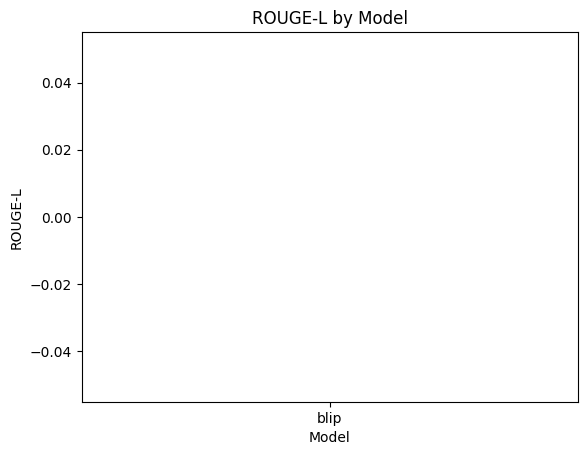

In [20]:
# Bar charts for BLEU and ROUGE-L
plt.figure()
plt.bar(summary_df["model"], summary_df["BLEU_avg"])
plt.title("Average BLEU by Model")
plt.xlabel("Model")
plt.ylabel("BLEU")

plt.figure()
plt.bar(summary_df["model"], summary_df["ROUGE_L"])
plt.title("ROUGE-L by Model")
plt.xlabel("Model")
plt.ylabel("ROUGE-L")

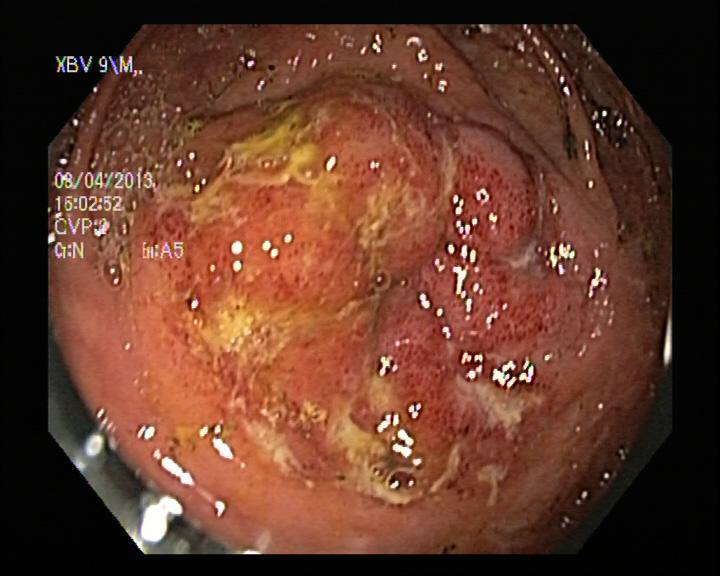

Image ID: cla820gl0s3o7071u4ouwcitb
Q: Are there any abnormalities in the image? Check all that are present.
GT: ulcerative colitis

[blip] pred: are there any abnormalities in the image? check all that are present. | BLEU: 0.00
[blip2] pred: Are there any abnormalities in the image? Check all that are present. | BLEU: 0.00
[git] pred: question : are there any abnormalities in the image? check all that are present. answer : | BLEU: 0.00
[vilt] pred: no | BLEU: 0.00


In [26]:
def show_side_by_side(detail_df, img_idx=0):
    """
    Shows the same (img, question) across all models with predictions.
    Assumes detail_df contains multiple models' rows for the same img_id/question.
    """
    # pick one (img_id, question) pair
    pivot_cols = ["img_id", "question"]
    grp = (detail_df.groupby(pivot_cols).size().reset_index(name="count")
                     .sort_values("count", ascending=False))
    if img_idx >= len(grp):
        print("Index out of range for grouped pairs; try a smaller img_idx.")
        return

    img_id = grp.iloc[img_idx]["img_id"]
    question = grp.iloc[img_idx]["question"]

    subset = detail_df[(detail_df["img_id"] == img_id) & (detail_df["question"] == question)]\
             .sort_values("model")

    if subset.empty:
        print("No rows found for the chosen pair.")
        return

    from IPython.display import display
    img_path = subset.iloc[0]["img_path"]
    display(Image.open(img_path).convert("RGB"))

    print(f"Image ID: {img_id}\nQ: {question}\nGT: {subset.iloc[0]['ground_truth']}\n")
    for _, r in subset.iterrows():
        print(f"[{r['model']}] pred: {r['predicted']} | BLEU: {r['bleu']:.2f}")

show_side_by_side(detail_df, img_idx=0)  # change idx to view others

In [28]:
# CONCLUSION 

# baseline off-the-shelf VQA models perform poorly on Kvasir-VQA

In [ ]:
# Build a CNN-based baseline

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

# Preprocessing for ResNet (standard ImageNet normalization)
cnn_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

In [ ]:
# Defining CNN Based VQA Model

In [30]:
class CNNVQABaseline(nn.Module):
    def __init__(self, num_answers, embed_dim=256, hidden_dim=256):
        super().__init__()
        # Pretrained ResNet backbone
        self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet.fc = nn.Identity()  # take features before final FC
        img_dim = 2048

        # Text embedding (simple GRU)
        self.word_emb = nn.Embedding(10000, embed_dim)  # vocab size ~10k
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        # Fusion + classifier
        fusion_dim = img_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_answers)
        )

    def forward(self, images, questions):
        # images: [B,3,224,224]
        img_feat = self.resnet(images)  # [B, 2048]

        # questions: [B, T]
        q_emb = self.word_emb(questions)
        _, h = self.gru(q_emb) 
        q_feat = h.squeeze(0)   

        fused = torch.cat([img_feat, q_feat], dim=1)
        out = self.classifier(fused)
        return out

In [31]:
from collections import Counter

# Choose top 100 answers as the label space
N_ANSWERS = 100
answer_counts = Counter(df_uc["answer"].astype(str))
top_answers = [a for a, _ in answer_counts.most_common(N_ANSWERS)]
ans2idx = {a:i for i,a in enumerate(top_answers)}
idx2ans = {i:a for a,i in ans2idx.items()}

def encode_answer(ans):
    return ans2idx.get(ans, None) 


In [32]:
class UC_VQADataset(torch.utils.data.Dataset):
    def __init__(self, df, transform, ans2idx, max_len=16):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.ans2idx = ans2idx
        self.max_len = max_len

        # simple tokenizer (whitespace split)
        self.word2idx = {"<pad>":0, "<unk>":1}
        self.idx2word = {0:"<pad>", 1:"<unk>"}
        self.vocab_size = 2

    def tokenize(self, text):
        tokens = text.lower().split()
        ids = []
        for t in tokens:
            if t not in self.word2idx:
                self.word2idx[t] = self.vocab_size
                self.idx2word[self.vocab_size] = t
                self.vocab_size += 1
            ids.append(self.word2idx[t])
        return ids

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        image = self.transform(image)

        q_ids = self.tokenize(str(row["question"]))
        if len(q_ids) < self.max_len:
            q_ids += [0]*(self.max_len - len(q_ids))
        else:
            q_ids = q_ids[:self.max_len]
        q_ids = torch.tensor(q_ids)

        ans = encode_answer(str(row["answer"]))
        return image, q_ids, ans

In [ ]:
# Training Loop

In [34]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torchvision import models


train_df = df_uc[df_uc["answer"].isin(top_answers)].sample(1000, random_state=SEED)
val_df   = train_df.sample(200, random_state=SEED)

train_ds = UC_VQADataset(train_df, cnn_transform, ans2idx)
val_ds   = UC_VQADataset(val_df,   cnn_transform, ans2idx)


def safe_collate(batch):
    imgs, qs, ans = [], [], []
    for b in batch:
        try:
            x_img, x_q, x_a = b
            if x_a is None:
                continue
            imgs.append(x_img)
            qs.append(x_q)
            ans.append(x_a)
        except Exception:
            # skip any sample that errors in __getitem__
            continue
    if len(imgs) == 0:
        # return empty tensors so the training loop can skip
        return (torch.empty(0, 3, 224, 224), torch.empty(0, 16, dtype=torch.long), torch.empty(0, dtype=torch.long))
    return (torch.stack(imgs, 0),
            torch.stack(qs,   0).long(),
            torch.tensor(ans, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=safe_collate)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=safe_collate)


class CNNVQABaseline(nn.Module):
    def __init__(self, num_answers, embed_dim=256, hidden_dim=256):
        super().__init__()
        # Try new torchvision weights API first, fall back to old string if needed
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V1
            self.resnet = models.resnet50(weights=weights)
        except Exception:
            self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet.fc = nn.Identity()   # take penultimate features
        img_dim = 2048

        self.word_emb = nn.Embedding(10000, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        fusion_dim = img_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_answers)
        )

    def forward(self, images, questions):
        img_feat = self.resnet(images)               # [B, 2048]
        q_emb = self.word_emb(questions)             # [B, T, E]
        _, h = self.gru(q_emb)                       # h: [1, B, H]
        q_feat = h.squeeze(0)                        # [B, H]
        fused = torch.cat([img_feat, q_feat], dim=1) # [B, 2048+H]
        return self.classifier(fused)                # [B, num_answers]

model_cnn = CNNVQABaseline(num_answers=N_ANSWERS).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)


for epoch in range(2):
    model_cnn.train()
    total_loss = 0.0                      # ✅ <-- the missing value
    num_batches = 0

    for imgs, qs, ans in train_loader:
        if imgs.shape[0] == 0:            # empty batch (all dropped) → skip
            continue
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)

        out = model_cnn(imgs, qs)
        loss = criterion(out, ans)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = (total_loss / max(1, num_batches))
    print(f"Epoch {epoch+1}: Train loss = {avg_loss:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/aristotle/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:01<00:00, 81.9MB/s]


Epoch 1: Train loss = 2.7718
Epoch 2: Train loss = 2.1234


In [35]:
model_cnn.eval()
all_preds, all_refs = [], []

with torch.no_grad():
    for imgs, qs, ans in val_loader:
        if imgs.shape[0] == 0:
            continue
        imgs, qs = imgs.to(DEVICE), qs.to(DEVICE)
        out = model_cnn(imgs, qs)
        pred_idx = torch.argmax(out, dim=1).cpu().tolist()
        preds = [idx2ans[i] for i in pred_idx]
        refs  = [idx2ans[a.item()] if a.item() in idx2ans else "" for a in ans]

        all_preds.extend(preds)
        all_refs.extend(refs)

bleus  = [compute_bleu(p, r) for p, r in zip(all_preds, all_refs)]
bleu_cnn  = sum(bleus)/len(bleus) if bleus else 0.0
rouge_cnn = compute_rougeL(all_preds, all_refs) if all_preds else 0.0
print(f"CNN baseline → BLEU: {bleu_cnn:.3f}, ROUGE-L: {rouge_cnn:.3f}")

CNN baseline → BLEU: 0.068, ROUGE-L: 0.380


In [ ]:
# Merging Results 

In [36]:
# Merge with CNN baseline metrics
import pandas as pd
from pathlib import Path
import numpy as np

# 1. Load summary if not already in memory
if 'summary_df' not in globals():
    phase3_summary_path = Path("phase3_results/summary_uc_phase3.csv")
    if phase3_summary_path.exists():
        summary_df = pd.read_csv(phase3_summary_path)
    else:
        summary_df = pd.DataFrame(columns=["model","n_examples","BLEU_avg","ROUGE_L","time_sec","time_per_example_sec"])

# 2) Build combined table
combined = summary_df[["model","n_examples","BLEU_avg","ROUGE_L"]].copy() if not summary_df.empty else pd.DataFrame(columns=["model","n_examples","BLEU_avg","ROUGE_L"])

# CNN metrics from your previous cell (bleu_cnn, rouge_cnn, all_preds)
cnn_row = {
    "model": "cnn_baseline",
    "n_examples": len(all_preds) if 'all_preds' in globals() else np.nan,
    "BLEU_avg": float(bleu_cnn) if 'bleu_cnn' in globals() else np.nan,
    "ROUGE_L": float(rouge_cnn) if 'rouge_cnn' in globals() else np.nan,
}
combined = pd.concat([combined, pd.DataFrame([cnn_row])], ignore_index=True)

# 3. Sort by BLEU (desc) and show
combined = combined.sort_values("BLEU_avg", ascending=False).reset_index(drop=True)
print("=== CNN vs Transformer on UC subset ===")
display(combined)

# 4. Simple improvement readout vs CNN
if "cnn_baseline" in combined["model"].values:
    base_bleu = combined.loc[combined["model"]=="cnn_baseline","BLEU_avg"].values[0]
    base_rouge = combined.loc[combined["model"]=="cnn_baseline","ROUGE_L"].values[0]
    # pick the best non-CNN model by BLEU
    non_cnn = combined[combined["model"]!="cnn_baseline"]
    if not non_cnn.empty:
        leader = non_cnn.iloc[0]
        abs_bleu_gain = leader["BLEU_avg"] - base_bleu
        abs_rouge_gain = leader["ROUGE_L"] - base_rouge
        print(f"\nBest transformer by BLEU: {leader['model']}")
        print(f"Absolute BLEU gain vs CNN: {abs_bleu_gain:.4f}")
        print(f"Absolute ROUGE-L gain vs CNN: {abs_rouge_gain:.4f}")
        if base_bleu > 0:
            rel_bleu = 100.0 * abs_bleu_gain / base_bleu
            print(f"Relative BLEU improvement: {rel_bleu:.1f}%")
        else:
            print("Relative BLEU improvement undefined (CNN BLEU == 0). Reporting absolute gain instead.")

=== CNN vs Transformer on UC subset ===


,model,n_examples,BLEU_avg,ROUGE_L
0,cnn_baseline,200,0.067575,0.380000
1,vilt,30,0.037746,0.222222
2,blip,30,0.000000,0.000000
3,git,30,0.000000,0.000000
4,blip2,30,0.000000,0.000000



Best transformer by BLEU: vilt
Absolute BLEU gain vs CNN: -0.0298
Absolute ROUGE-L gain vs CNN: -0.1578
Relative BLEU improvement: -44.1%


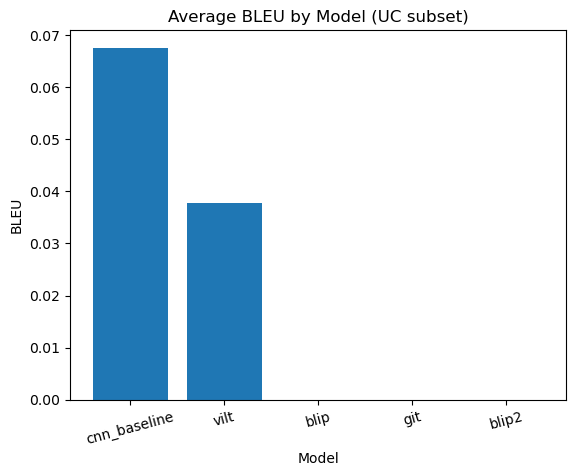

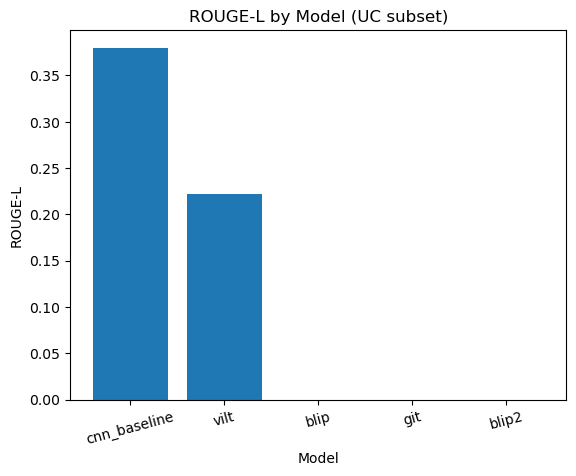

In [37]:
import matplotlib.pyplot as plt

# Guard against empty frame
if not combined.empty:
    plt.figure()
    plt.bar(combined["model"], combined["BLEU_avg"])
    plt.title("Average BLEU by Model (UC subset)")
    plt.xlabel("Model")
    plt.ylabel("BLEU")
    plt.xticks(rotation=15)

    plt.figure()
    plt.bar(combined["model"], combined["ROUGE_L"])
    plt.title("ROUGE-L by Model (UC subset)")
    plt.xlabel("Model")
    plt.ylabel("ROUGE-L")
    plt.xticks(rotation=15)
else:
    print("No results to plot. Make sure Phase 3 summary and CNN metrics exist.")